In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
orders = pd.read_csv(r'D:\Instamart\orders.csv') # orders
prod = pd.read_csv(r'D:\Instamart\products.csv')    # products 
cart = pd.read_csv(r'D:\Instamart\order_products__prior.csv')   # order_product_prior
aisle = pd.read_csv(r'D:\Instamart\aisles.csv') # aisle
dept = pd.read_csv(r'D:\Instamart\departments.csv') #department


In [3]:
cart.columns = cart.columns.str.strip()
prod.columns = prod.columns.str.strip()
orders.columns = orders.columns.str.strip()
aisle.columns = aisle.columns.str.strip()
dept.columns = dept.columns.str.strip()

In [4]:
df = pd.merge(cart, prod[['product_id', 'aisle_id', 'product_name']], on='product_id', how='left')

print(df.head())


   order_id  product_id  add_to_cart_order  reordered  aisle_id  \
0         2       33120                  1          1        86   
1         2       28985                  2          1        83   
2         2        9327                  3          0       104   
3         2       45918                  4          1        19   
4         2       30035                  5          0        17   

            product_name  
0     Organic Egg Whites  
1  Michigan Organic Kale  
2          Garlic Powder  
3         Coconut Butter  
4      Natural Sweetener  


In [5]:
transactions = df[['order_id', 'product_name']]
transactions = df.groupby('order_id')['product_name'].apply(list).tolist()

In [6]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder() 
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions, sparse=True)  
trial_1 = pd.DataFrame.sparse.from_spmatrix(te_array, columns=te.columns_) 

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12020\1440869623.py:6: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  trial_1 = pd.DataFrame.sparse.from_spmatrix(te_array, columns=te.columns_)


In [ ]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder

# Grouping the data by 'order_id' and aggregating 'product_name' and 'aisle_id' into lists
transaction_data = df[['order_id', 'product_name', 'aisle_id']]
transaction_data_grouped = transaction_data.groupby('order_id').agg(list).reset_index()

# Create transactions by combining 'product_name' and 'aisle_id'
transactions = []
for _, row in transaction_data_grouped.iterrows():
    transaction = [
        f"{prod}_{aisle}" for prod, aisle in zip(row['product_name'], row['aisle_id'])
    ]
    transactions.append(transaction)

# Apply TransactionEncoder to the combined data
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions, sparse=True)

# Convert to DataFrame
mba_df = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

# Display the resulting DataFrame
print(mba_df)


In [ ]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

transactions = []
for _, row in transaction_data_grouped.iterrows():
    transaction = []

    for prod, aisle in zip(row['product_name'], row['aisle_id']):
        transaction.append(f"{prod}_{aisle}") 
    transactions.append(transaction)

te_ary = te.fit(transactions).transform(transactions, sparse=True)

mba_df = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

print(mba_df)


In [ ]:
print("Number of features (columns):", mba_df.shape[1])

Number of features (columns): 49677


In [8]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(trial_1, min_support=0.01, use_colnames=True, low_memory=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0, num_itemsets=3)

print(rules.head(20))

                 antecedents               consequents  antecedent support  \
0   (Bag of Organic Bananas)    (Organic Baby Spinach)            0.118030   
1     (Organic Baby Spinach)  (Bag of Organic Bananas)            0.075251   
2   (Bag of Organic Bananas)    (Organic Hass Avocado)            0.118030   
3     (Organic Hass Avocado)  (Bag of Organic Bananas)            0.066436   
4   (Bag of Organic Bananas)     (Organic Raspberries)            0.118030   
5      (Organic Raspberries)  (Bag of Organic Bananas)            0.042632   
6   (Bag of Organic Bananas)    (Organic Strawberries)            0.118030   
7     (Organic Strawberries)  (Bag of Organic Bananas)            0.082331   
8                   (Banana)             (Large Lemon)            0.146993   
9              (Large Lemon)                  (Banana)            0.047485   
10         (Organic Avocado)                  (Banana)            0.054999   
11                  (Banana)         (Organic Avocado)          

In [9]:
maps = pd.DataFrame(df)
print(maps.head())

   order_id  product_id  add_to_cart_order  reordered  aisle_id  \
0         2       33120                  1          1        86   
1         2       28985                  2          1        83   
2         2        9327                  3          0       104   
3         2       45918                  4          1        19   
4         2       30035                  5          0        17   

            product_name  
0     Organic Egg Whites  
1  Michigan Organic Kale  
2          Garlic Powder  
3         Coconut Butter  
4      Natural Sweetener  


In [10]:
maps = pd.merge(maps, orders[['order_id', 'order_hour_of_day', 'days_since_prior_order']], on='order_id', how='left')
print(maps.head(10))

   order_id  product_id  add_to_cart_order  reordered  aisle_id  \
0         2       33120                  1          1        86   
1         2       28985                  2          1        83   
2         2        9327                  3          0       104   
3         2       45918                  4          1        19   
4         2       30035                  5          0        17   
5         2       17794                  6          1        83   
6         2       40141                  7          1       105   
7         2        1819                  8          1        88   
8         2       43668                  9          0       123   
9         3       33754                  1          1       120   

                                        product_name  order_hour_of_day  \
0                                 Organic Egg Whites                  9   
1                              Michigan Organic Kale                  9   
2                                    

In [ ]:
maps['product_hour'] = maps['product_name'] + '_hour_' + maps['order_hour_of_day'].astype(str)

transactions2 = df.groupby('order_id')['product_hour'].apply(list).tolist()

print(transactions2[:5])


In [ ]:
print(df['product_name'].nunique())

49677


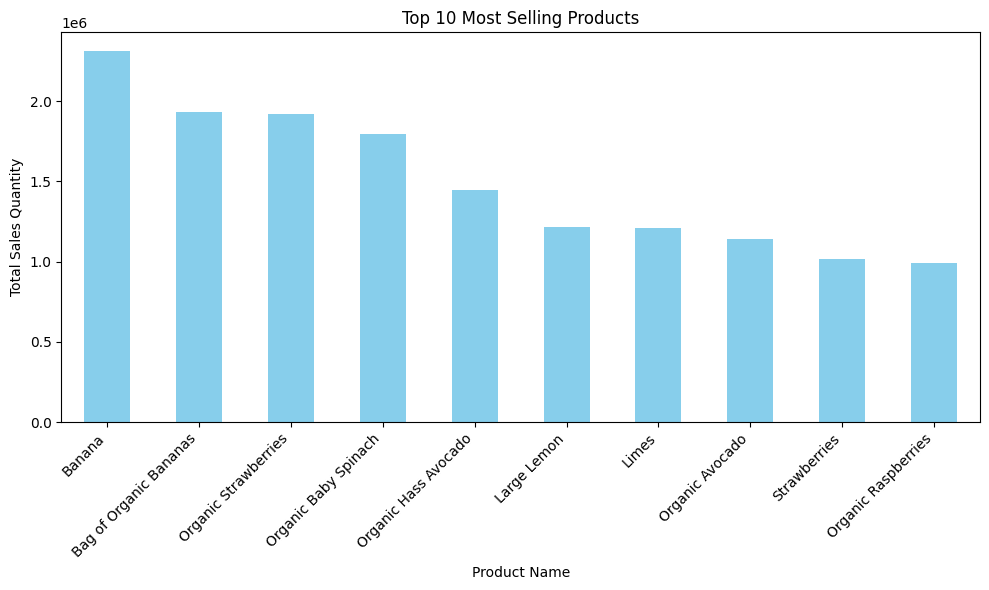

In [ ]:
top_products = df.groupby('product_name')['add_to_cart_order'].sum().sort_values(ascending=False).head(10)

# Create a bar plot
plt.figure(figsize=(10, 6))
top_products.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Selling Products')
plt.xlabel('Product Name')
plt.ylabel('Total Sales Quantity')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
print(top_products)

product_name
Banana                    2312794
Bag of Organic Bananas    1933657
Organic Strawberries      1918661
Organic Baby Spinach      1797386
Organic Hass Avocado      1447034
Large Lemon               1213412
Limes                     1206836
Organic Avocado           1139505
Strawberries              1017253
Organic Raspberries        988734
Name: add_to_cart_order, dtype: int64


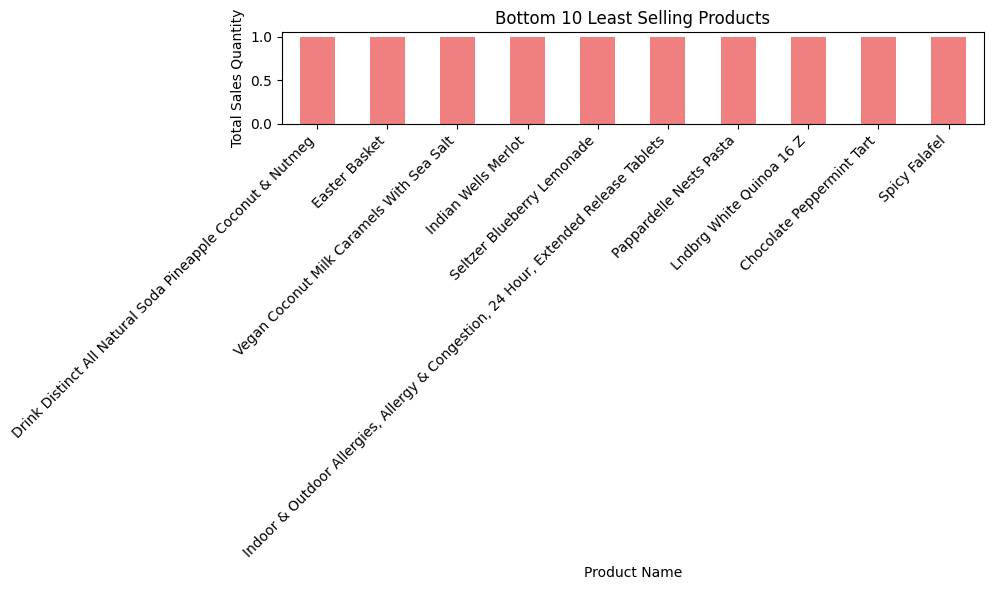

In [ ]:
import matplotlib.pyplot as plt

# Group by 'product_name' and sum the 'quantity' (or any column that tracks sales)
least_products = df.groupby('product_name')['add_to_cart_order'].sum().sort_values(ascending=True).head(10)

# Create a bar plot
plt.figure(figsize=(10, 6))
least_products.plot(kind='bar', color='lightcoral')
plt.title('Bottom 10 Least Selling Products')
plt.xlabel('Product Name')
plt.ylabel('Total Sales Quantity')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
# List the columns in your dataframe
print(maps.columns)


Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered',
       'product_name', 'order_hour_of_day', 'days_since_prior_order'],
      dtype='object')


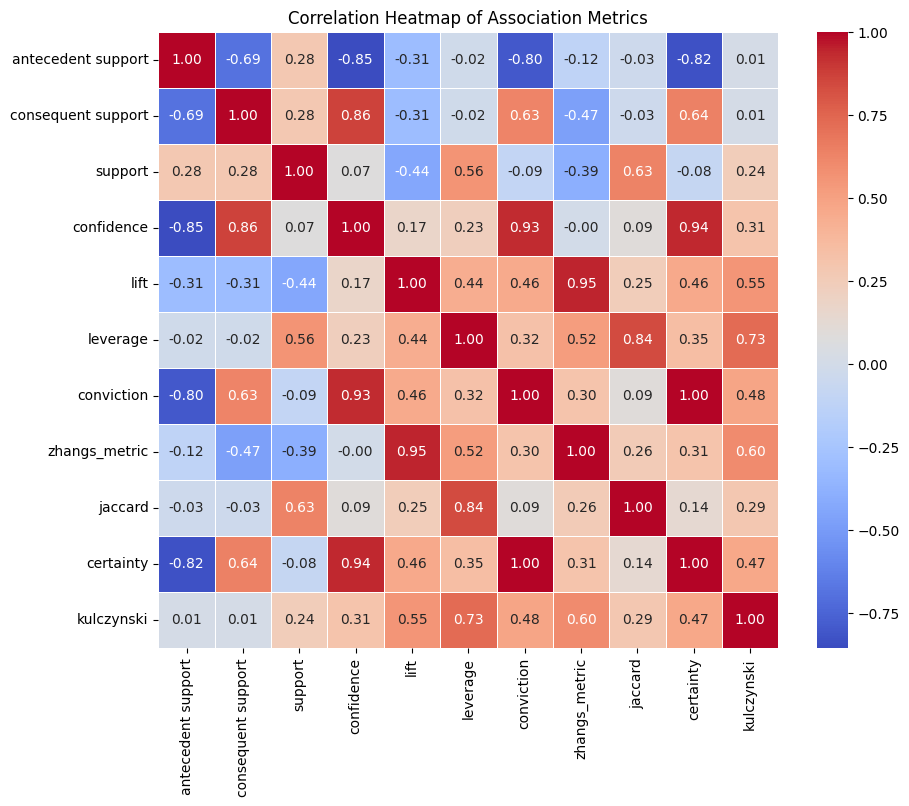

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'rules' contains the association rules with the relevant metrics
heatmap_data = rules[['antecedent support', 'consequent support', 'support', 'confidence', 'lift', 'leverage', 
                      'conviction', 'zhangs_metric', 'jaccard', 'certainty', 'kulczynski']]

# Calculate the correlation matrix
corr_matrix = heatmap_data.corr()

# Create the heatmap
plt.figure(figsize=(10, 8))  # Set the size of the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True, linewidths=0.5)

# Add title and labels
plt.title('Correlation Heatmap of Association Metrics')
plt.show()


   order_hour_of_day           product_name
0                  9     Organic Egg Whites
1                  9  Michigan Organic Kale
2                  9          Garlic Powder
3                  9         Coconut Butter
4                  9      Natural Sweetener
Filtered purchase counts for top 10 products:
product_name       Banana  Bag of Organic Bananas  Organic Strawberries  \
order_hour_of_day                                                         
0                    2815                    2712                  1839   
1                    1398                    1381                   869   
2                     820                     808                   463   
3                     589                     574                   331   
4                     686                     606                   384   

product_name       Organic Baby Spinach  Organic Hass Avocado  \
order_hour_of_day                                               
0                                 

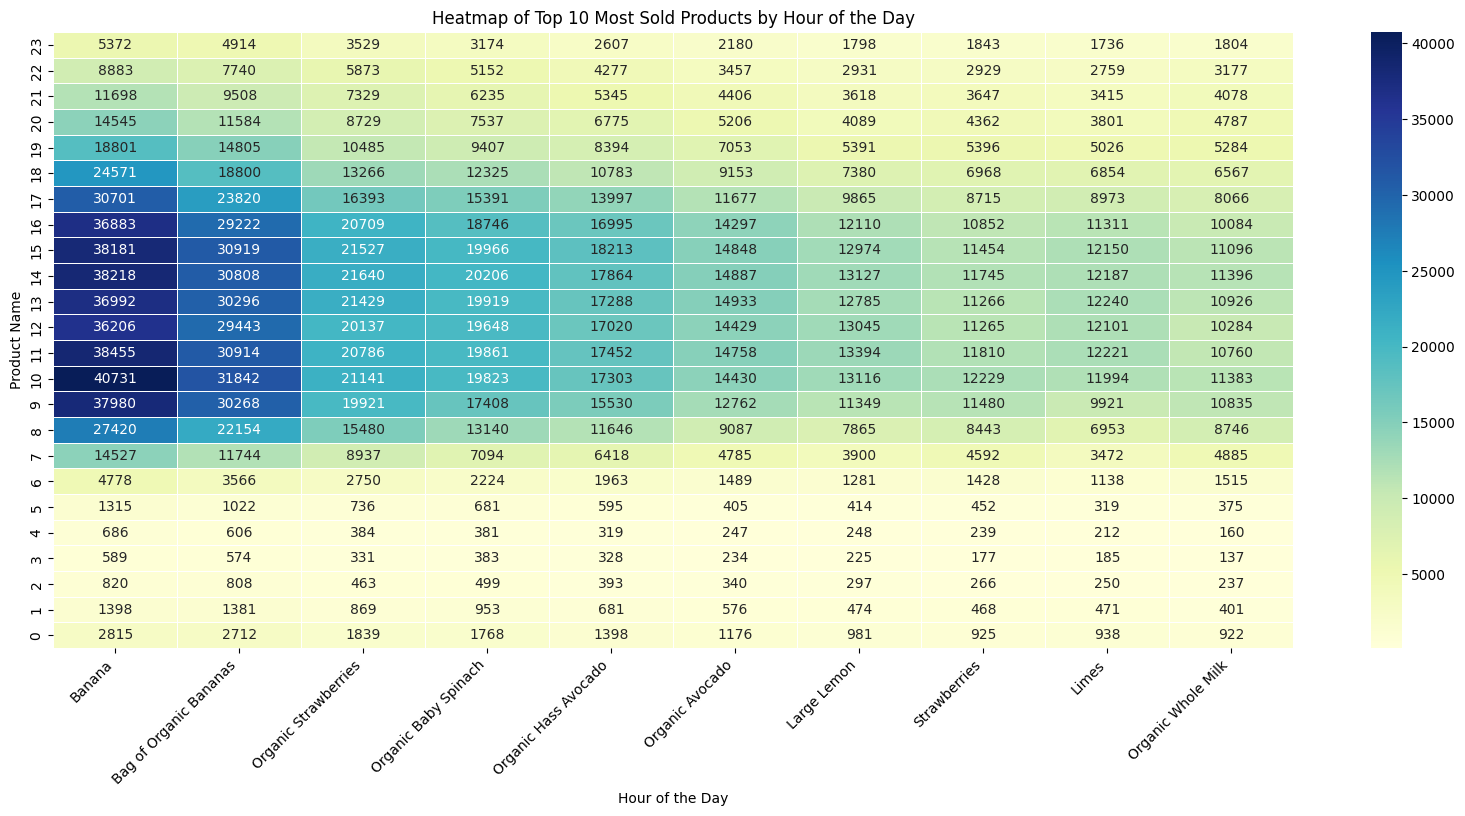

In [ ]:
# Check the first few rows of the data to ensure 'order_hour_of_day' and 'product_name' are correct
print(maps[['order_hour_of_day', 'product_name']].head())

# Group by 'order_hour_of_day' and 'product_name' and count the occurrences (sales)
purchase_counts = maps.groupby(['order_hour_of_day', 'product_name']).size().unstack(fill_value=0)

# Find the top 10 most sold products (highest total sales across all hours)
top_10_products = purchase_counts.sum(axis=0).nlargest(10).index

# Filter the data to include only the top 10 products
purchase_counts_top_10 = purchase_counts[top_10_products]

# Check the filtered data
print("Filtered purchase counts for top 10 products:")
print(purchase_counts_top_10.head())  # Check the first few rows of the filtered data

# Create the heatmap
plt.figure(figsize=(20, 8))  # Set the size of the heatmap
sns.heatmap(purchase_counts_top_10, cmap='YlGnBu', annot=True, fmt="d", cbar=True, linewidths=0.5)

# Reverse the y-axis (product names)
plt.gca().invert_yaxis()

# Add title and labels
plt.title('Heatmap of Top 10 Most Sold Products by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Product Name')
plt.xticks(rotation=45, ha='right')  # Rotate the x-axis labels for better readability

# Show the plot
plt.show()


   order_hour_of_day           product_name
0                  9     Organic Egg Whites
1                  9  Michigan Organic Kale
2                  9          Garlic Powder
3                  9         Coconut Butter
4                  9      Natural Sweetener
Filtered purchase counts for top 10 products:
product_name       Banana  Bag of Organic Bananas  Organic Strawberries  \
order_hour_of_day                                                         
0                    2815                    2712                  1839   
1                    1398                    1381                   869   
2                     820                     808                   463   
3                     589                     574                   331   
4                     686                     606                   384   

product_name       Organic Baby Spinach  Organic Hass Avocado  \
order_hour_of_day                                               
0                                 

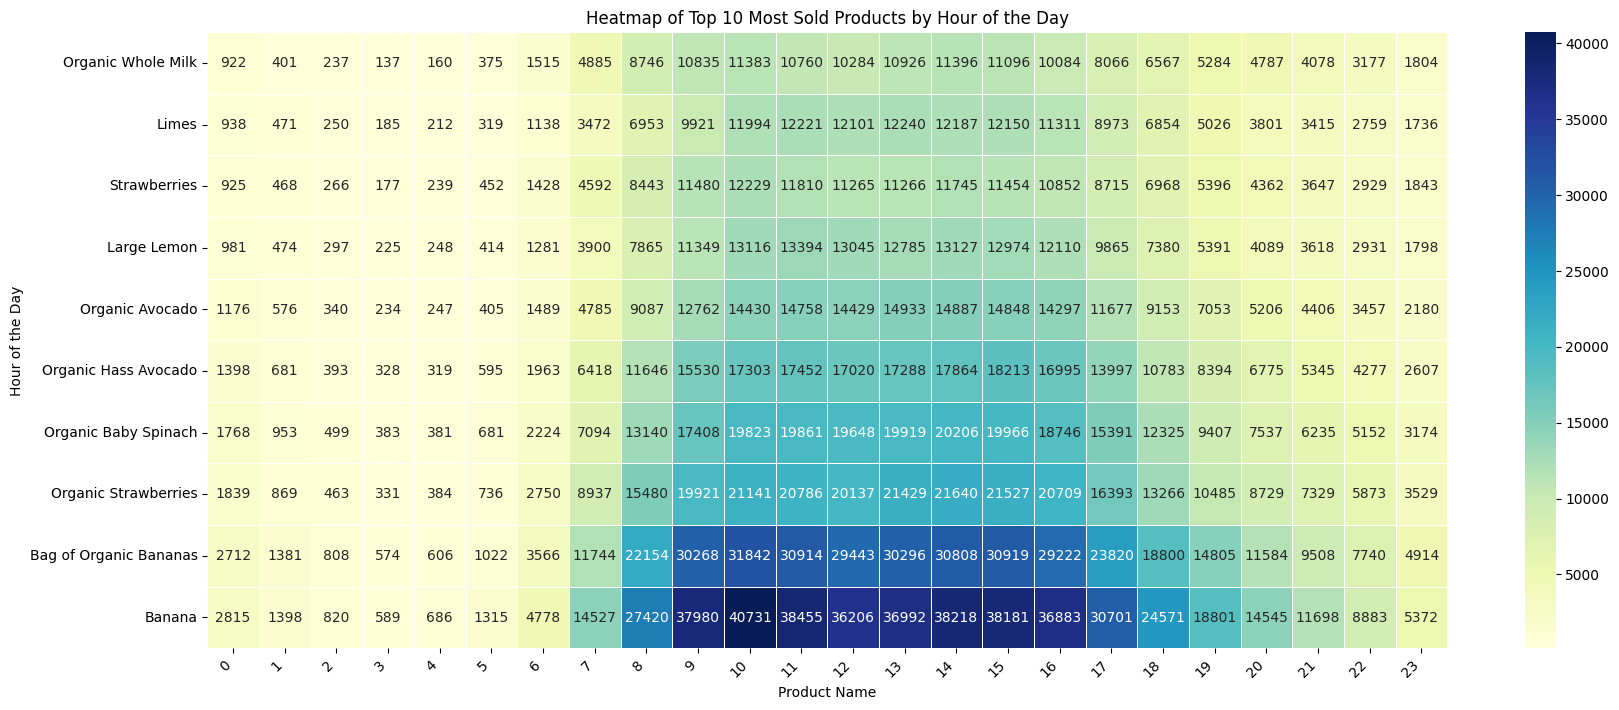

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print(maps[['order_hour_of_day', 'product_name']].head())

# Group by 'order_hour_of_day' and 'product_name' and count the occurrences (sales)
purchase_counts = maps.groupby(['order_hour_of_day', 'product_name']).size().unstack(fill_value=0)

top_10_products = purchase_counts.sum(axis=0).nlargest(10).index

purchase_counts_top_10 = purchase_counts[top_10_products]

print("Filtered purchase counts for top 10 products:")
print(purchase_counts_top_10.head()) 

plt.figure(figsize=(20, 8)) 
sns.heatmap(purchase_counts_top_10.T, cmap='YlGnBu', annot=True, fmt="d", cbar=True, linewidths=0.5)

plt.gca().invert_yaxis()
plt.title('Heatmap of Top 10 Most Sold Products by Hour of the Day')
plt.xlabel('Product Name')
plt.ylabel('Hour of the Day')
plt.xticks(rotation=45, ha='right')  # Rotate the x-axis labels 
plt.show()


In [ ]:
# Group data by hour and product
product_hour_sales = maps.groupby(['order_hour_of_day', 'product_name']).size().unstack(fill_value=0)

# Check the resulting DataFrame
print(product_hour_sales.head())



product_name       #2 Coffee Filters  #2 Cone White Coffee Filters  \
order_hour_of_day                                                    
0                                  3                             0   
1                                  4                             0   
2                                  4                             0   
3                                  1                             0   
4                                  0                             0   

product_name       #2 Mechanical Pencils  #4 Natural Brown Coffee Filters  \
order_hour_of_day                                                           
0                                      0                                3   
1                                      0                                0   
2                                      0                                0   
3                                      1                                0   
4                                      0       

In [ ]:
# Transpose the DataFrame for correlation between hours
hourly_sales_correlation = product_hour_sales.T.corr()

# Check the correlation matrix
print(hourly_sales_correlation)

order_hour_of_day        0         1         2         3         4         5   \
order_hour_of_day                                                               
0                  1.000000  0.992381  0.987546  0.982311  0.984591  0.987108   
1                  0.992381  1.000000  0.987602  0.982452  0.982549  0.982199   
2                  0.987546  0.987602  1.000000  0.981411  0.979851  0.978580   
3                  0.982311  0.982452  0.981411  1.000000  0.978168  0.975152   
4                  0.984591  0.982549  0.979851  0.978168  1.000000  0.982259   
5                  0.987108  0.982199  0.978580  0.975152  0.982259  1.000000   
6                  0.984461  0.975890  0.971754  0.966737  0.976923  0.990105   
7                  0.984609  0.975086  0.970952  0.965554  0.975274  0.988776   
8                  0.985300  0.976928  0.973341  0.968028  0.977105  0.989029   
9                  0.982687  0.975527  0.972473  0.967448  0.975951  0.986264   
10                 0.985907 

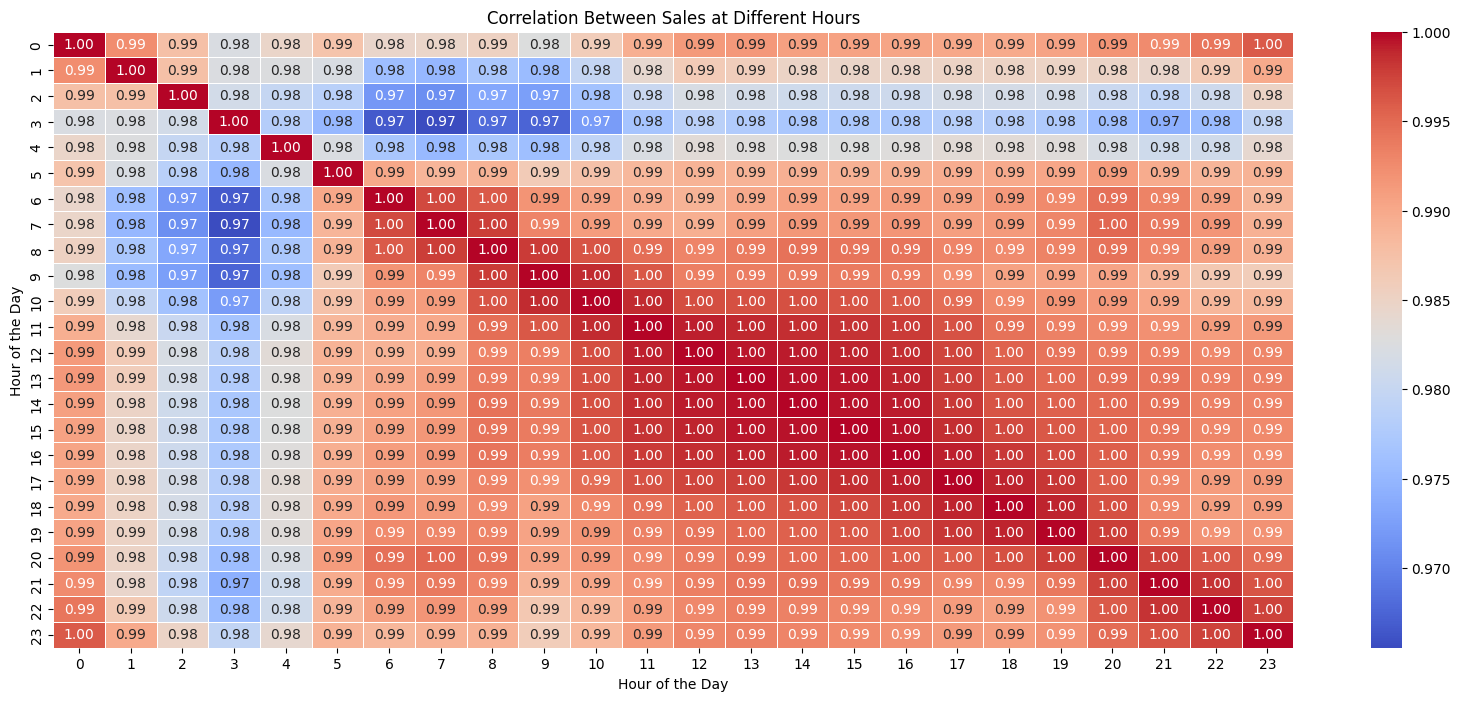

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
sns.heatmap(hourly_sales_correlation, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Sales at Different Hours')
plt.xlabel('Hour of the Day')
plt.ylabel('Hour of the Day')
plt.show()


In [ ]:
top_products = maps['product_name'].value_counts().head(10).index

# Filter the DataFrame for top products
top_product_sales = maps[maps['product_name'].isin(top_products)]

# Aggregate sales data for these products
popular_product_sales = top_product_sales.groupby(['order_hour_of_day', 'product_name']).size().unstack(fill_value=0)


In [ ]:
# Correlation matrix for popular products
product_correlation = popular_product_sales.corr()

# Check the correlation matrix
print(product_correlation)


product_name            Bag of Organic Bananas    Banana  Large Lemon  \
product_name                                                            
Bag of Organic Bananas                1.000000  0.999443     0.995370   
Banana                                0.999443  1.000000     0.994053   
Large Lemon                           0.995370  0.994053     1.000000   
Limes                                 0.992708  0.990961     0.999312   
Organic Avocado                       0.995977  0.995194     0.998254   
Organic Baby Spinach                  0.997651  0.996595     0.998136   
Organic Hass Avocado                  0.997656  0.996956     0.997277   
Organic Strawberries                  0.998616  0.997720     0.993421   
Organic Whole Milk                    0.996994  0.995758     0.988231   
Strawberries                          0.999603  0.998944     0.994925   

product_name               Limes  Organic Avocado  Organic Baby Spinach  \
product_name                                    

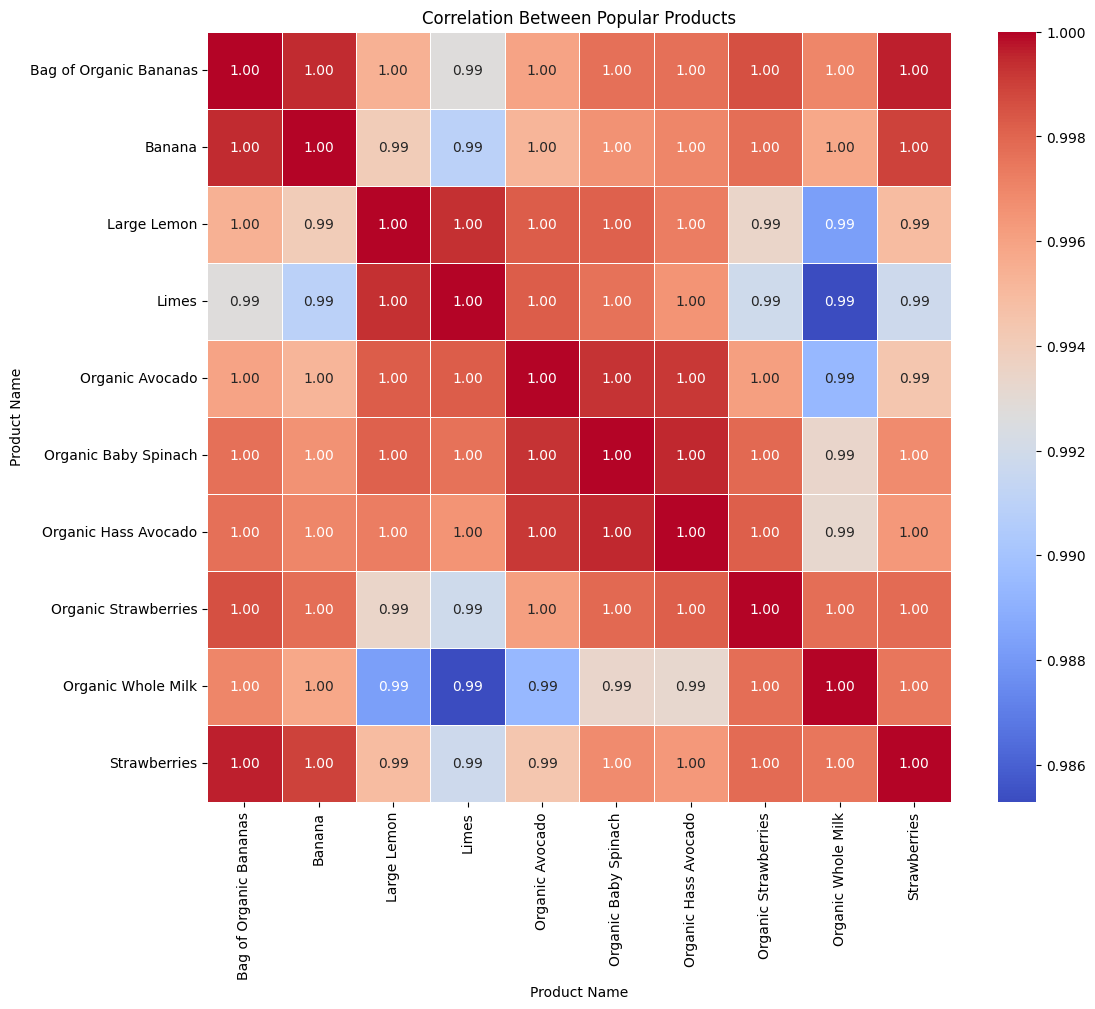

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(product_correlation, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Popular Products')
plt.xlabel('Product Name')
plt.ylabel('Product Name')
plt.xticks(rotation=90)
plt.show()


In [ ]:
product_hour_sales = maps.groupby(['order_hour_of_day', 'product_name']).size().unstack(fill_value=0) 

In [ ]:
print(product_hour_sales.index)


Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23],
      dtype='int64', name='order_hour_of_day')


In [ ]:
banana_product_sales = product_hour_sales['Banana']

print(banana_product_sales)


order_hour_of_day
0      2815
1      1398
2       820
3       589
4       686
5      1315
6      4778
7     14527
8     27420
9     37980
10    40731
11    38455
12    36206
13    36992
14    38218
15    38181
16    36883
17    30701
18    24571
19    18801
20    14545
21    11698
22     8883
23     5372
Name: Banana, dtype: int64


In [ ]:
# , first 20 products)
other_products_sales = product_hour_sales.iloc[:, :10] 

sales_data = pd.concat([product_hour_sales['Banana'], other_products_sales], axis=1)

correlation_matrix = sales_data.corr()

print(correlation_matrix['Banana'])


Banana                                           1.000000
#2 Coffee Filters                                0.987987
#2 Cone White Coffee Filters                     0.506768
#2 Mechanical Pencils                            0.338602
#4 Natural Brown Coffee Filters                  0.897333
& Go! Hazelnut Spread + Pretzel Sticks           0.894819
'Swingtop' Premium Lager                        -0.012151
(70% Juice!) Mountain Raspberry Juice Squeeze    0.678051
+Energy Black Cherry Vegetable & Fruit Juice     0.651893
.5\" Waterproof Tape                             0.376720
0 Calorie Acai Raspberry Water Beverage          0.868333
Name: Banana, dtype: float64


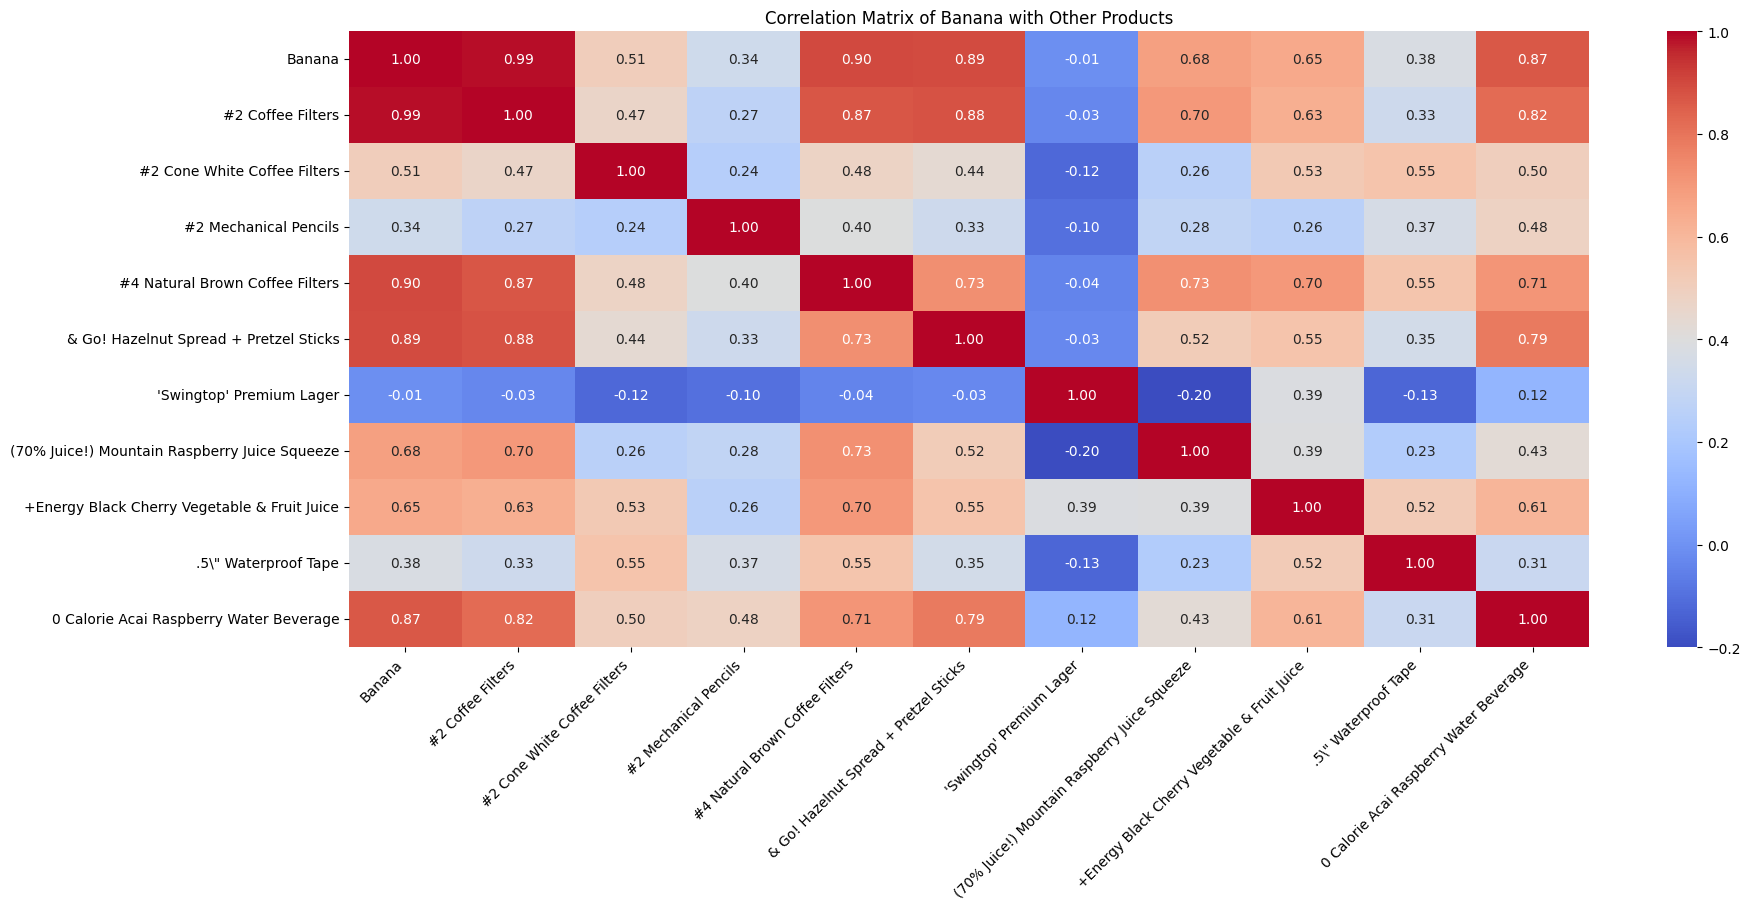

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(20, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.xticks(rotation=45, ha='right')
plt.title('Correlation Matrix of Banana with Other Products')
plt.show()


In [ ]:
other_products_sales = product_hour_sales.iloc[:, :10]

sales_data = pd.concat([product_hour_sales['Banana'], other_products_sales], axis=1)

# Calculate the correlation matrix for this subset
correlation_matrix = sales_data.corr()

# Display the correlation of Banana with other products
print(correlation_matrix['#2 Coffee Filters'])

Banana                                           0.987987
#2 Coffee Filters                                1.000000
#2 Cone White Coffee Filters                     0.469813
#2 Mechanical Pencils                            0.270041
#4 Natural Brown Coffee Filters                  0.871924
& Go! Hazelnut Spread + Pretzel Sticks           0.879061
'Swingtop' Premium Lager                        -0.034725
(70% Juice!) Mountain Raspberry Juice Squeeze    0.699986
+Energy Black Cherry Vegetable & Fruit Juice     0.633739
.5\" Waterproof Tape                             0.329966
0 Calorie Acai Raspberry Water Beverage          0.824088
Name: #2 Coffee Filters, dtype: float64


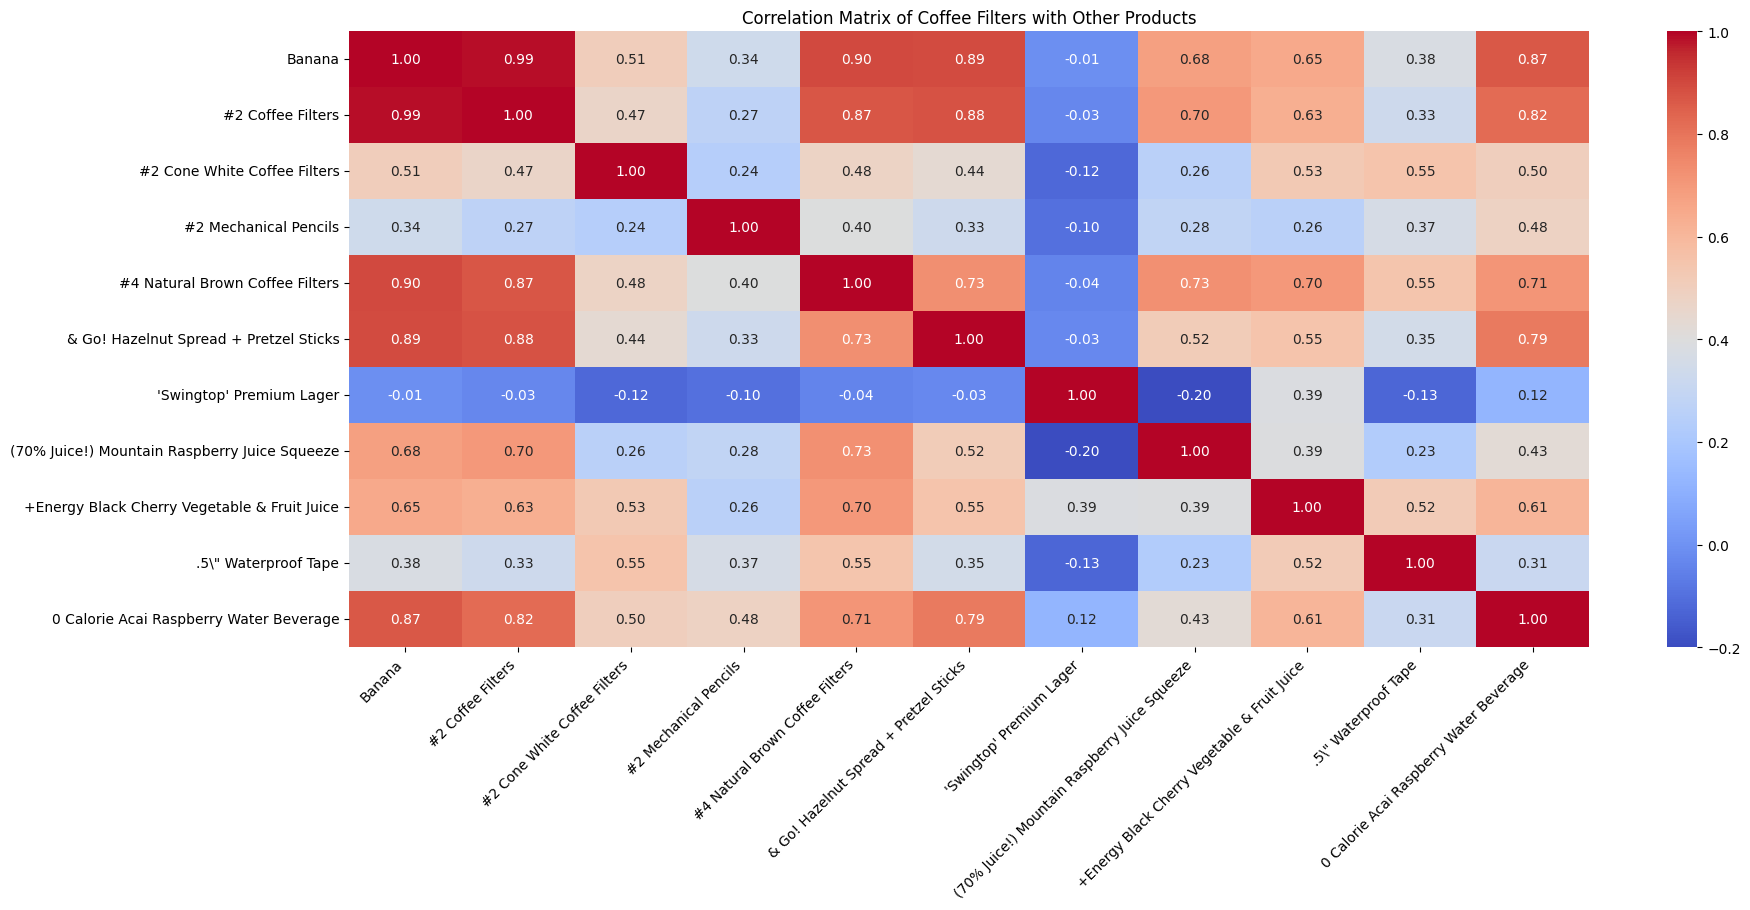

In [ ]:
plt.figure(figsize=(20, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.xticks(rotation=45, ha='right')
plt.title('Correlation Matrix of Coffee Filters with Other Products')
plt.show()

In [ ]:

total_sales = product_hour_sales.sum()

top_10_products = total_sales.sort_values(ascending=False).head(10)

print(top_10_products)


product_name
Banana                    472565
Bag of Organic Bananas    379450
Organic Strawberries      264683
Organic Baby Spinach      241921
Organic Hass Avocado      213584
Organic Avocado           176815
Large Lemon               152657
Strawberries              142951
Limes                     140627
Organic Whole Milk        137905
dtype: int64


                          Banana    Banana  Bag of Organic Bananas  \
Banana                  1.000000  1.000000                0.999443   
Banana                  1.000000  1.000000                0.999443   
Bag of Organic Bananas  0.999443  0.999443                1.000000   
Organic Strawberries    0.997720  0.997720                0.998616   
Organic Baby Spinach    0.996595  0.996595                0.997651   
Organic Hass Avocado    0.996956  0.996956                0.997656   
Organic Avocado         0.995194  0.995194                0.995977   
Large Lemon             0.994053  0.994053                0.995370   
Strawberries            0.998944  0.998944                0.999603   
Limes                   0.990961  0.990961                0.992708   
Organic Whole Milk      0.995758  0.995758                0.996994   

                        Organic Strawberries  Organic Baby Spinach  \
Banana                              0.997720              0.996595   
Banana             

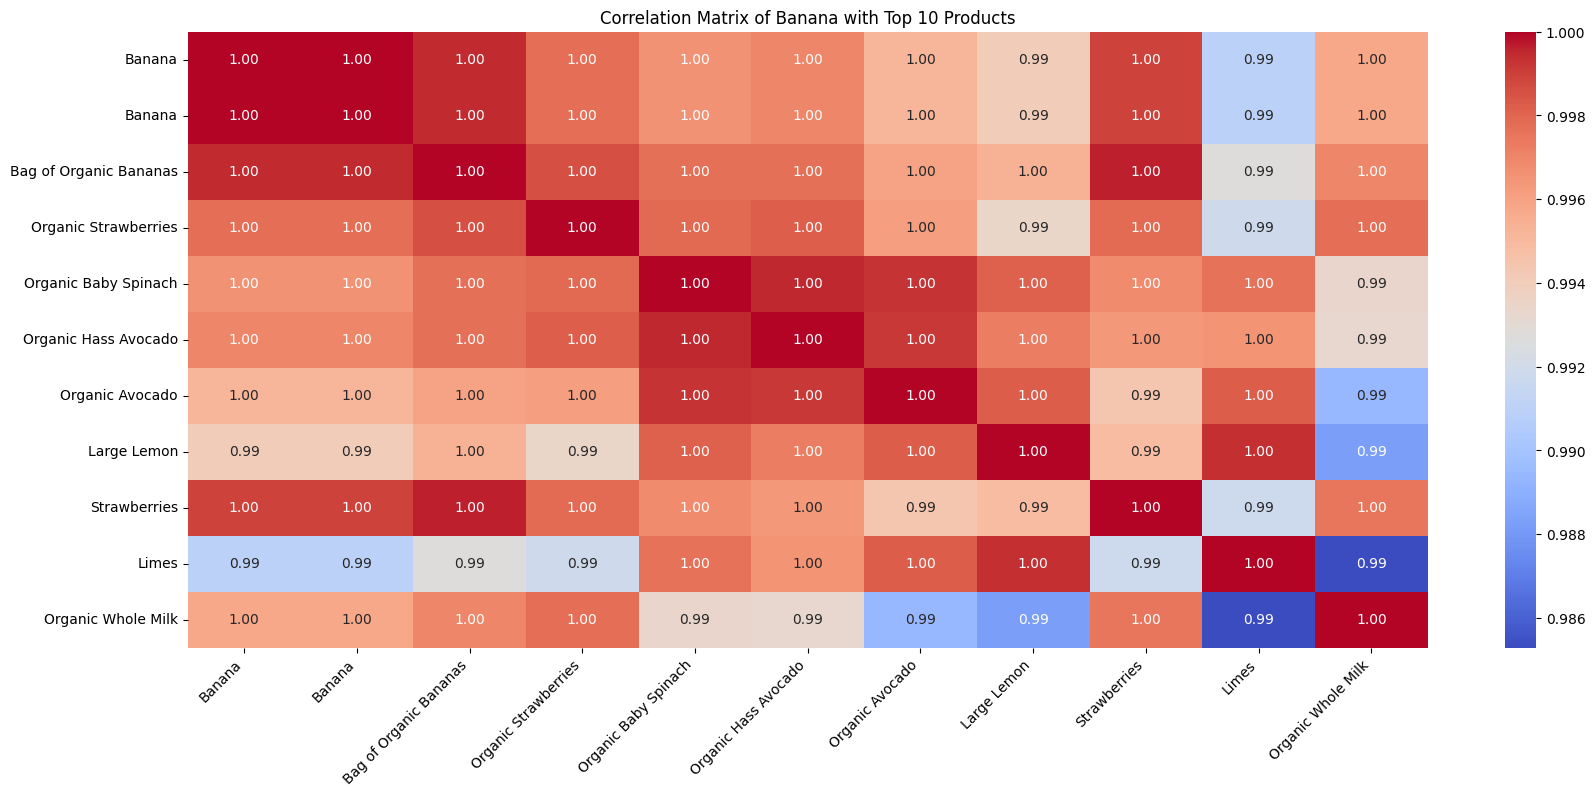

In [ ]:

top_10_sales_data = product_hour_sales[top_10_products.index]


sales_data = pd.concat([product_hour_sales['Banana'], top_10_sales_data], axis=1)


correlation_matrix = sales_data.corr()


print(correlation_matrix)

plt.figure(figsize=(20, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.xticks(rotation=45, ha='right')
plt.title('Correlation Matrix of Banana with Top 10 Products')
plt.show()


In [ ]:
print(maps.head())

   order_id  product_id  add_to_cart_order  reordered           product_name  \
0         2       33120                  1          1     Organic Egg Whites   
1         2       28985                  2          1  Michigan Organic Kale   
2         2        9327                  3          0          Garlic Powder   
3         2       45918                  4          1         Coconut Butter   
4         2       30035                  5          0      Natural Sweetener   

   order_hour_of_day  days_since_prior_order  
0                  9                     8.0  
1                  9                     8.0  
2                  9                     8.0  
3                  9                     8.0  
4                  9                     8.0  


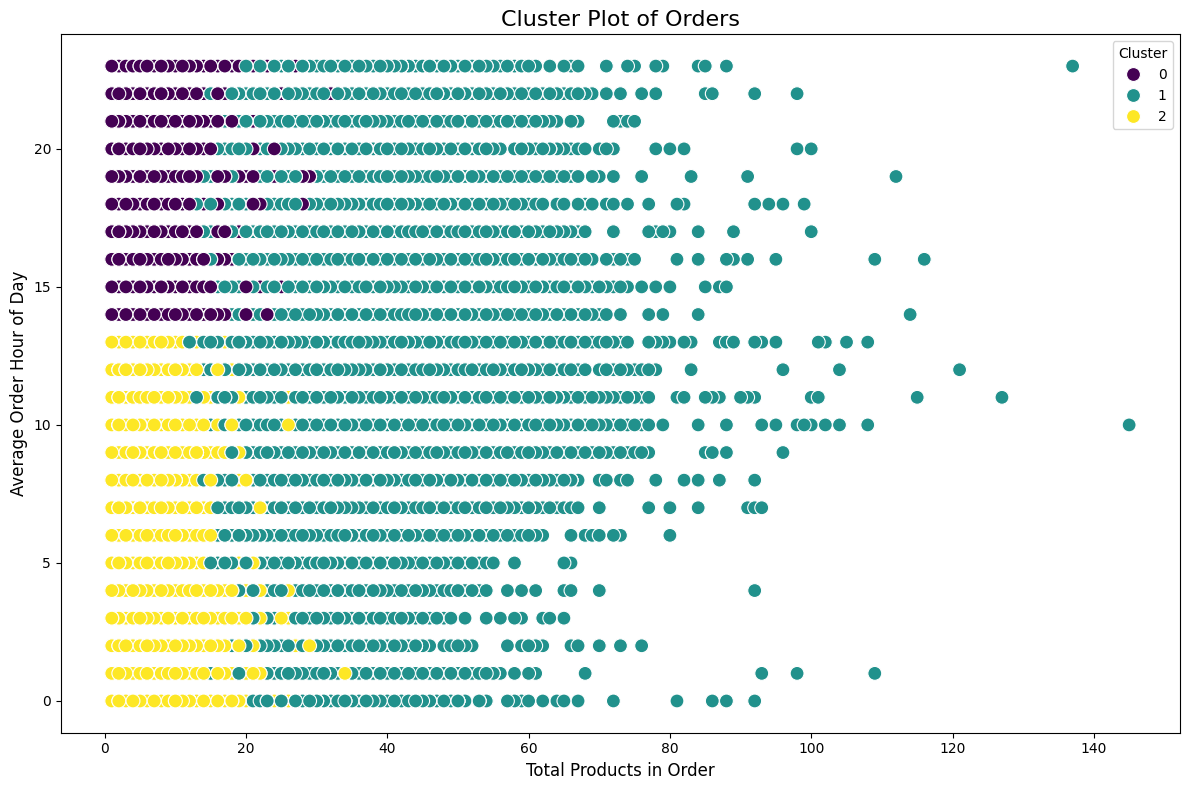

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Aggregate data by 'order_id'
order_aggregates = maps.groupby('order_id').agg({
    'product_id': 'count', 
    'order_hour_of_day': 'mean',  
    'reordered': 'sum'  
}).rename(columns={
    'product_id': 'total_products',
    'order_hour_of_day': 'avg_order_hour',
    'reordered': 'total_reorders'
})

scaler = StandardScaler()
scaled_data = scaler.fit_transform(order_aggregates)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # Adjust the number of clusters if needed
order_aggregates['cluster'] = kmeans.fit_predict(scaled_data)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=order_aggregates,
    x='total_products',
    y='avg_order_hour',
    hue='cluster',
    palette='viridis',
    s=100
)

plt.title('Cluster Plot of Orders', fontsize=16)
plt.xlabel('Total Products in Order', fontsize=12)
plt.ylabel('Average Order Hour of Day', fontsize=12)
plt.legend(title='Cluster', loc='upper right')
plt.tight_layout()
plt.show()


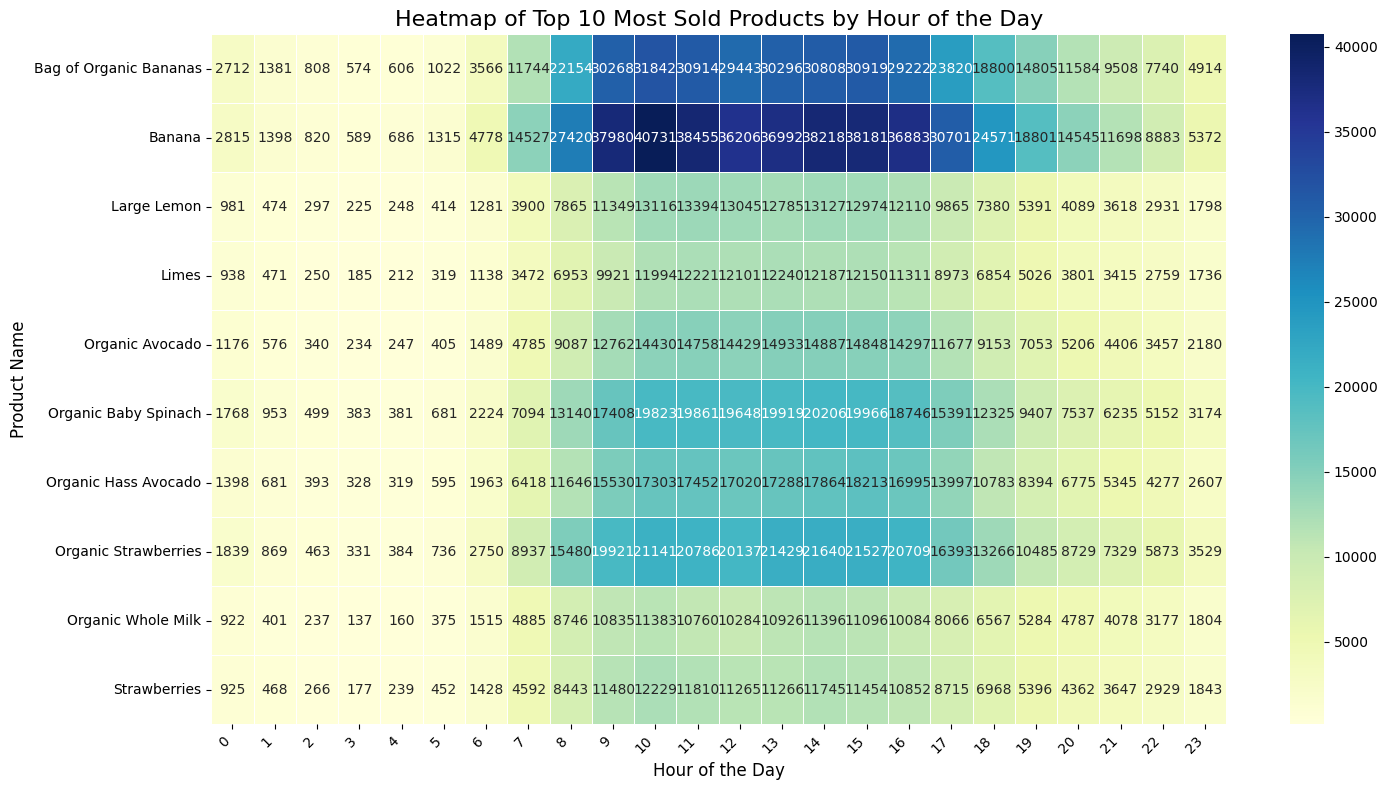

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

top_products = (
    maps['product_name']
    .value_counts()
    .nlargest(10)
    .index
)

top_products_data = maps[maps['product_name'].isin(top_products)]


hourly_sales = top_products_data.pivot_table(
    index='product_name',
    columns='order_hour_of_day',
    values='order_id',  
    aggfunc='count',
    fill_value=0  
)

plt.figure(figsize=(15, 8))
sns.heatmap(
    hourly_sales,
    cmap='YlGnBu',
    annot=True,  
    fmt='d',    
    linewidths=0.5
)

plt.title('Heatmap of Top 10 Most Sold Products by Hour of the Day', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()


In [ ]:
maps_grouped = maps.groupby(['order_id'])
maps_grouped_dataset = pd.DataFrame(maps_grouped.size())

print(maps_grouped_dataset.head(10))
print(maps_grouped.size().max())
print(maps_grouped.size().idxmax())

           0
order_id    
2          9
3          8
4         13
5         26
6          3
7          2
8          1
9         15
10        15
11         5
145
1564244


In [ ]:
maps_grouped_dataset = maps.groupby('order_id').size().reset_index(name='basket_size')
print(maps_grouped_dataset.head())

   order_id  basket_size
0         2            9
1         3            8
2         4           13
3         5           26
4         6            3


C:\Users\Administrator\AppData\Local\Temp\ipykernel_12376\1739425034.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Administrator\Desktop\python_projects\jupyter_python\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


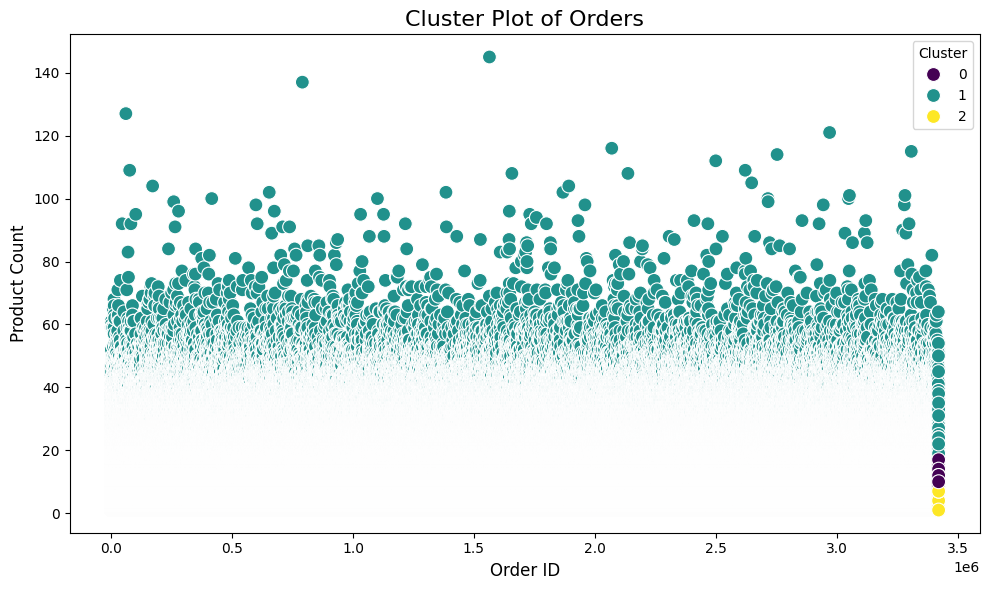

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



# Standardize the data 
scaler = StandardScaler()


scaled_data = scaler.fit_transform(maps_grouped_dataset[['basket_size']])

# Apply KMeans clustering 
kmeans = KMeans(n_clusters=3, random_state=42)
maps_grouped_dataset['cluster'] = kmeans.fit_predict(scaled_data)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=maps_grouped_dataset, x='order_id', y='basket_size', hue='cluster', palette='viridis', s=100)

plt.title('Cluster Plot of Orders', fontsize=16)
plt.xlabel('Order ID', fontsize=12)
plt.ylabel('Product Count', fontsize=12)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


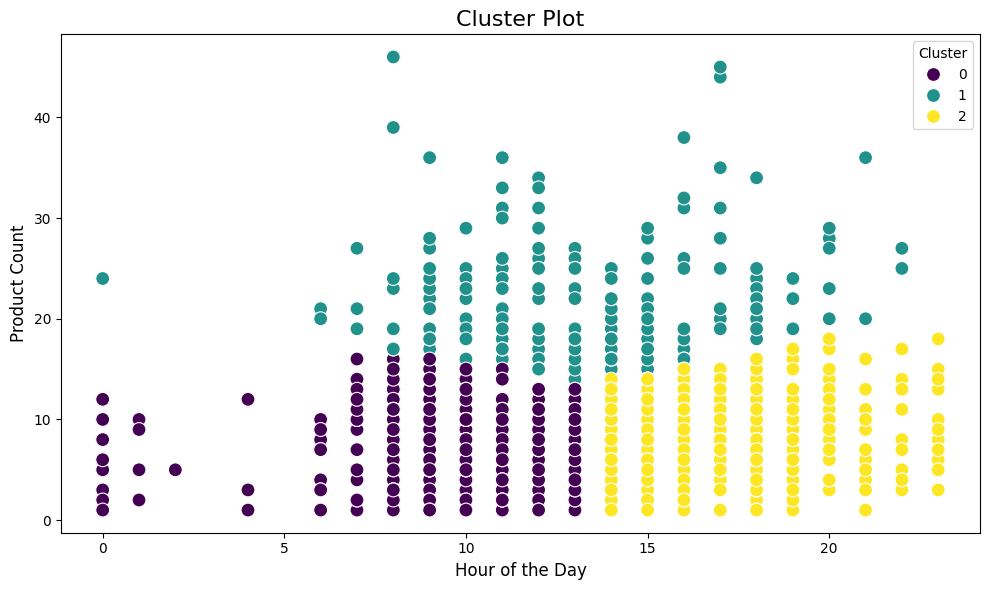

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Assuming maps is your dataset
# Filter the dataset to include the first 1,000 order IDs
filtered_data = maps.head(10000)

# Aggregate data by order_id to get the product count (assuming it's in your dataset)
order_aggregates = filtered_data.groupby('order_id').agg({
    'product_id': 'count',  # Total number of products in the order
    'order_hour_of_day': 'mean'  # Average hour of the order
}).rename(columns={
    'product_id': 'basket_size',
    'order_hour_of_day': 'avg_order_hour'
})

# Standardize the data for clustering (use 'product_count' and 'avg_order_hour' for clustering)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(order_aggregates[['basket_size', 'avg_order_hour']])

# Apply KMeans clustering (let's assume we want 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
order_aggregates['cluster'] = kmeans.fit_predict(scaled_data)

# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=order_aggregates, x='avg_order_hour', y='basket_size', hue='cluster', palette='viridis', s=100)

# Add plot title and labels
plt.title('Cluster Plot', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Product Count', fontsize=12)
plt.legend(title='Cluster')

# Show the plot
plt.tight_layout()
plt.show()
